In [157]:
!pip install keras-tuner

In [204]:
import pandas as pd
import numpy as np
import tensorflow as tf
from keras.layers import Dense
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner.tuners import RandomSearch
import keras_tuner as kt
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [159]:
df = pd.read_csv("diabetes.csv")

In [160]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


### Removing outlier

<Axes: ylabel='Pregnancies'>

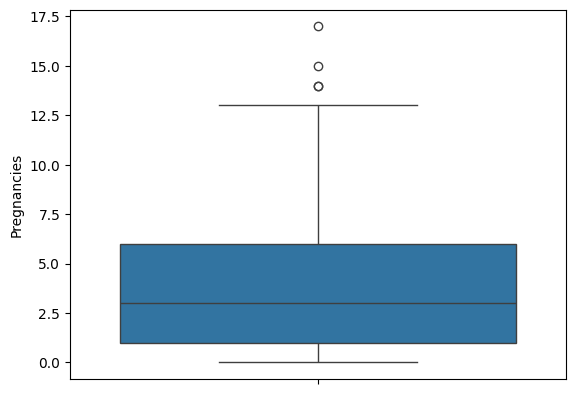

In [162]:
sns.boxplot(df["Pregnancies"])

### Remove outlier of pregnancies

In [163]:
df= df[df["Pregnancies"] <= 13]

### Handling glucose column

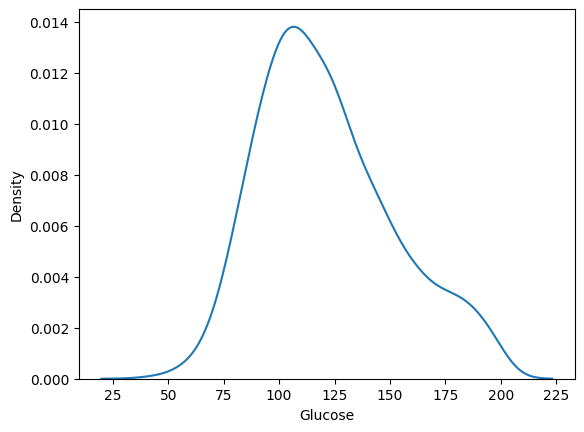

In [164]:
sns.kdeplot(df["Glucose"])
plt.show()

<Axes: ylabel='Glucose'>

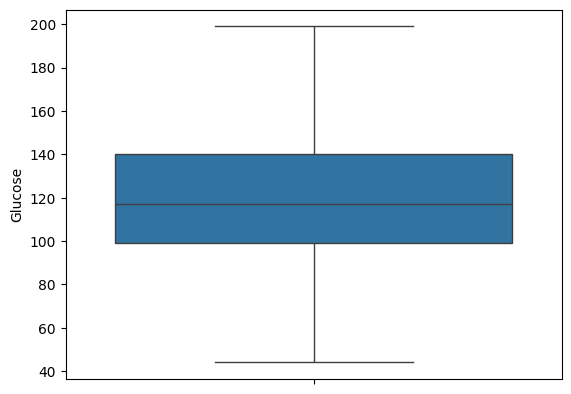

In [165]:
sns.boxplot(df["Glucose"])

### Handling BP column

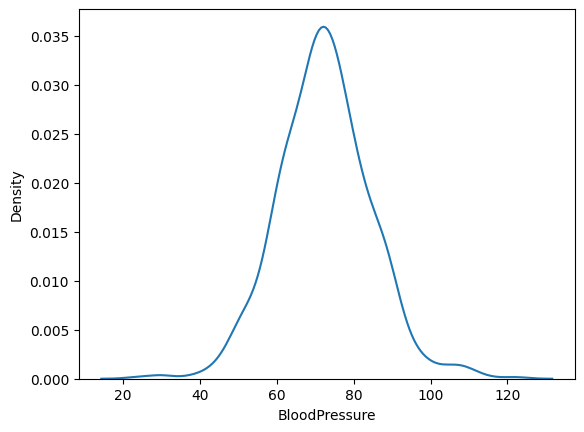

In [166]:
sns.kdeplot(df["BloodPressure"])
plt.show()

<Axes: ylabel='Glucose'>

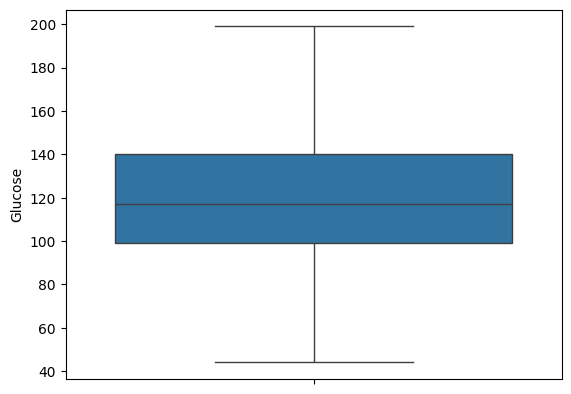

In [167]:
sns.boxplot(df["Glucose"])

### Handling Skin Thickness column

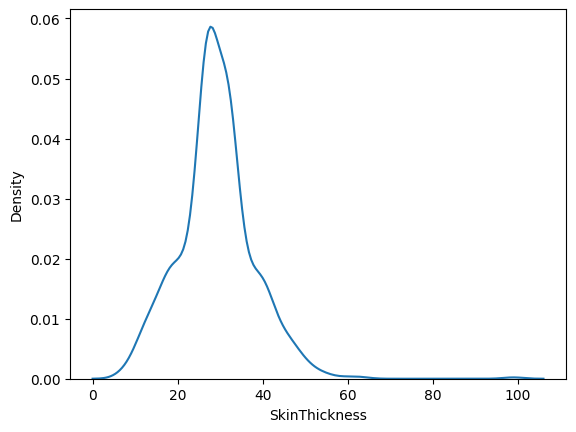

In [168]:
sns.kdeplot(df["SkinThickness"])
plt.show()

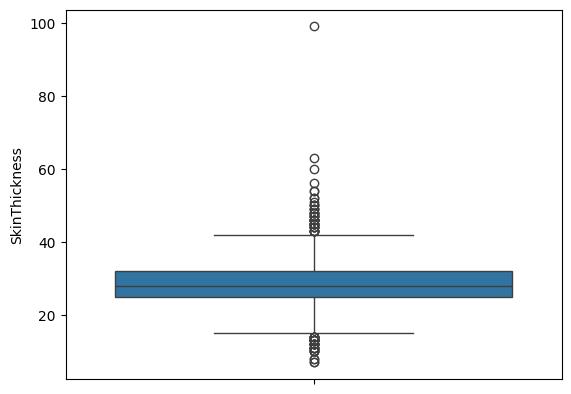

In [169]:
sns.boxplot(df["SkinThickness"])
plt.show()

### Insulin column

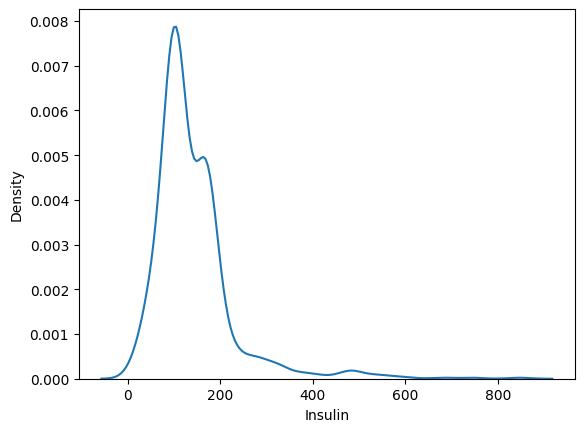

In [170]:
sns.kdeplot(df["Insulin"])
plt.show()

<Axes: ylabel='Insulin'>

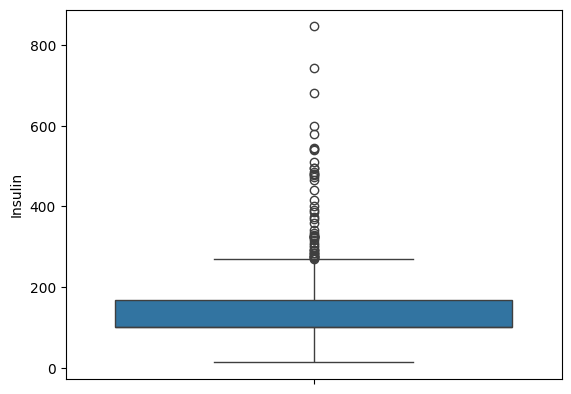

In [171]:
sns.boxplot(df["Insulin"])

In [172]:
df = df[df["Insulin"] <= 600]

### Handling BMI column

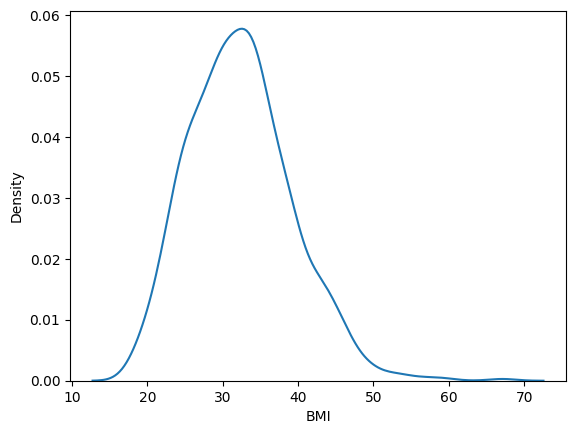

In [173]:
sns.kdeplot(df["BMI"])
plt.show()

<Axes: ylabel='BMI'>

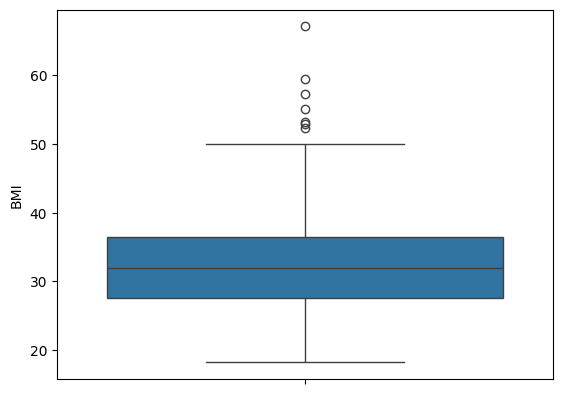

In [174]:
sns.boxplot(df["BMI"])

In [175]:
df = df[df["BMI"] <= 50]

### Handling DiabetesPedigreeFunction column

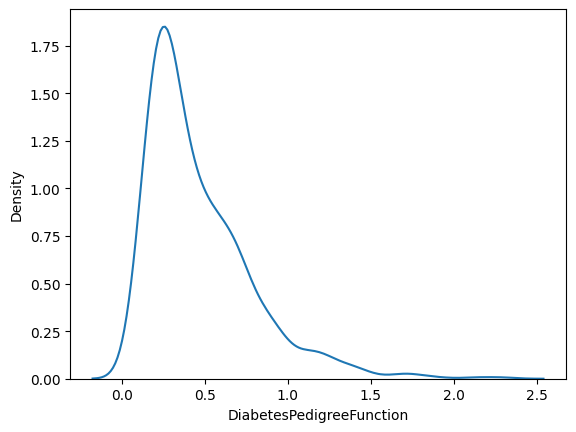

In [176]:
sns.kdeplot(df["DiabetesPedigreeFunction"])
plt.show()

<Axes: ylabel='DiabetesPedigreeFunction'>

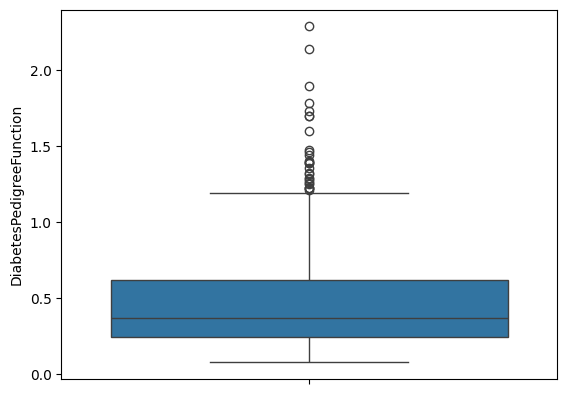

In [177]:
sns.boxplot(df["DiabetesPedigreeFunction"])

### Age distribution

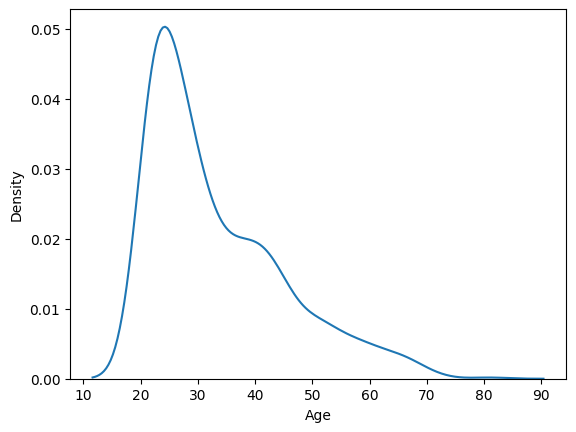

In [178]:
sns.kdeplot(df["Age"])
plt.show()

In [179]:
df['Age'].value_counts()

,count
Age,
22,71
21,63
24,46
25,46
23,37
28,34
27,32
26,31
29,29


<Axes: ylabel='Age'>

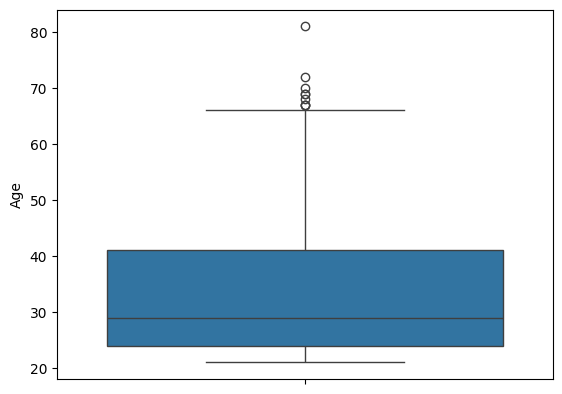

In [180]:
sns.boxplot(df["Age"])

In [181]:
df = df[df["Age"]<=70]

### Shape

In [182]:
df.shape

(752, 9)

### Correlation graph

<Axes: >

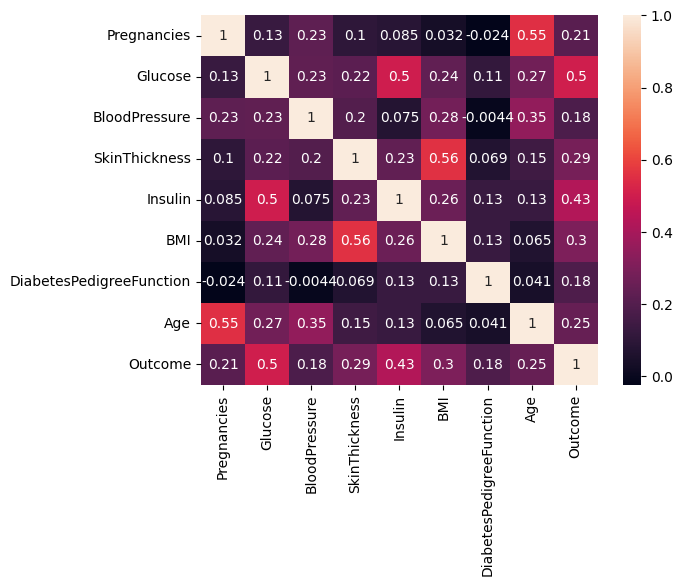

In [183]:
sns.heatmap(df.corr(), annot=True)

### Bivariate analysis

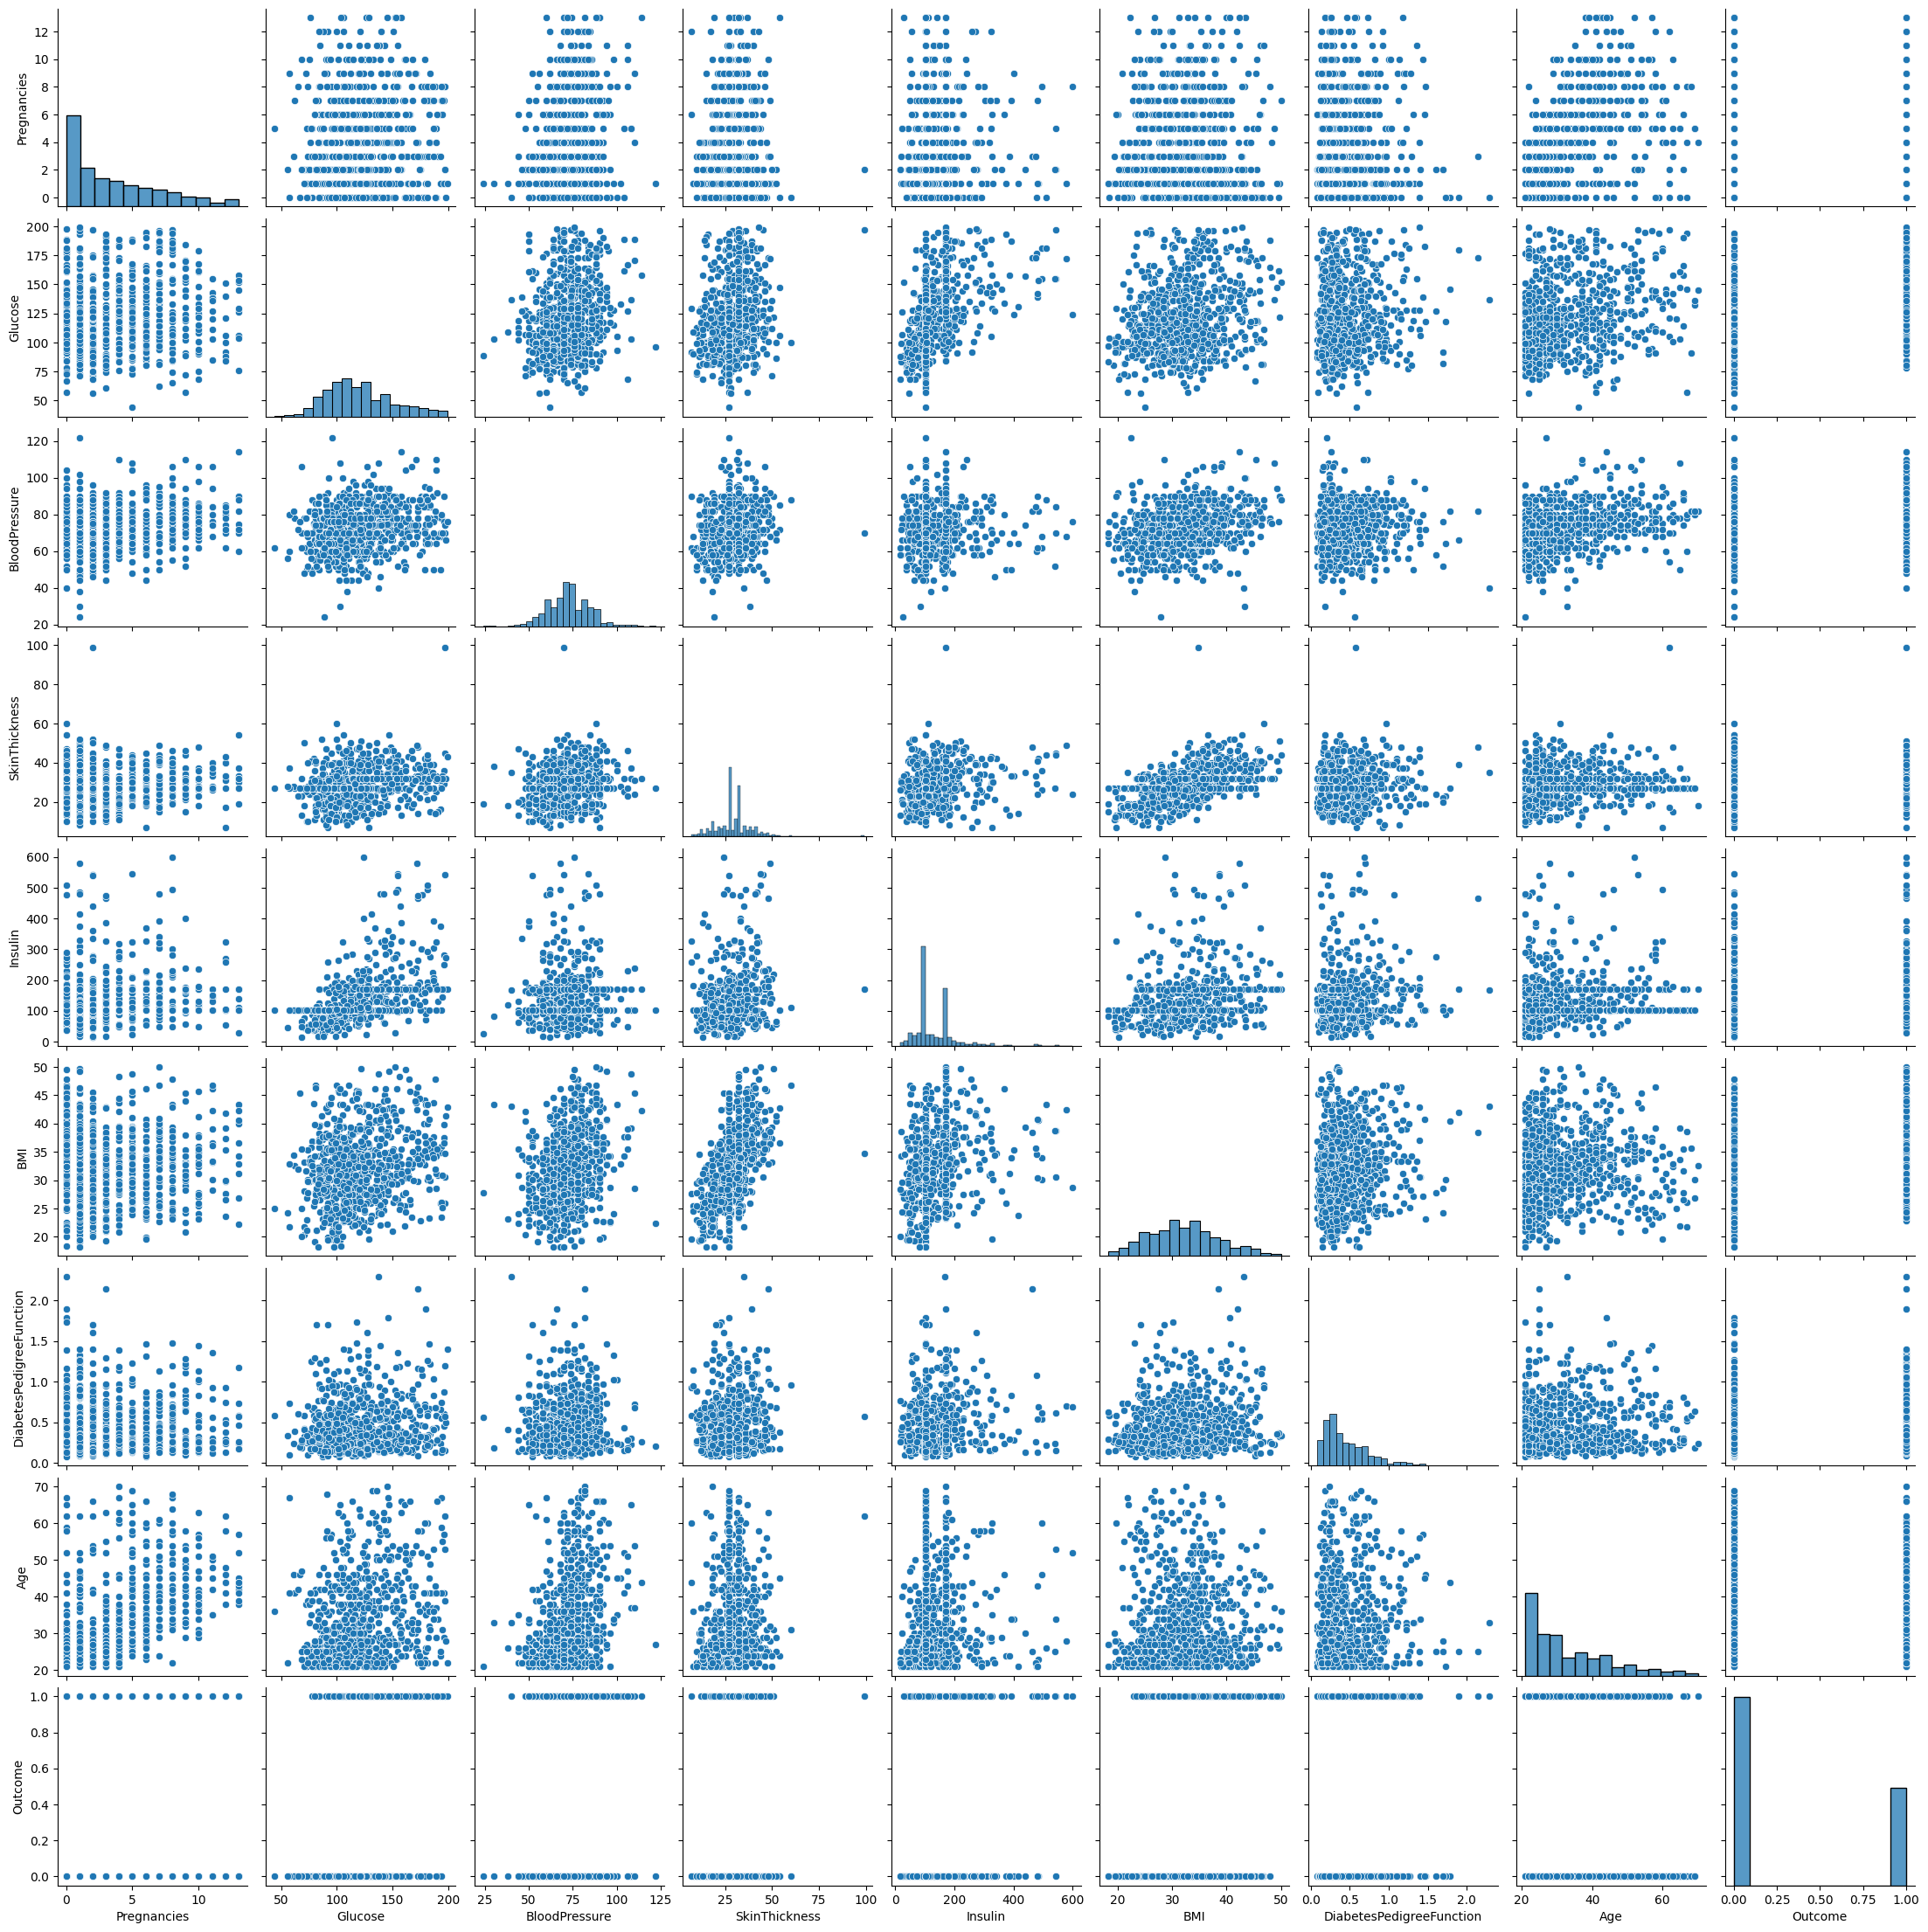

In [184]:
sns.pairplot(df)

### Model Building

In [185]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [186]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [187]:
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [188]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [189]:
callback = EarlyStopping(monitor='loss', patience=4)

In [190]:
model.fit(X_train, y_train, epochs=100, batch_size=10,validation_data=(X_test,y_test), callbacks=[callback])

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5158 - loss: 5.6781 - val_accuracy: 0.7020 - val_loss: 0.8896
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7304 - loss: 0.8014 - val_accuracy: 0.7947 - val_loss: 0.7288
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7055 - loss: 0.8490 - val_accuracy: 0.8278 - val_loss: 0.6351
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7504 - loss: 0.7745 - val_accuracy: 0.8278 - val_loss: 0.6161
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7388 - loss: 0.7074 - val_accuracy: 0.8278 - val_loss: 0.5966
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7504 - loss: 0.6659 - val_accuracy: 0.8146 - val_loss: 0.5816
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7471 - loss: 0.6376 - val_accuracy: 0.8477 - val_loss: 0.5440
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7654 - loss: 0.5920 - val_accuracy: 0.8609 - v

### Hyperparamater tunning

In [191]:
def build_model(hp):

    model = Sequential()

    # Input layer
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

    # Tune number of hidden layers
    for i in range(
        hp.Int("num_layers", min_value=1, max_value=5)
    ):

        # Tune number of nodes
        model.add(
            Dense(
                units=hp.Int(
                    "Str"+str(i),
                    min_value=16,
                    max_value=256,
                    step=16
                ),
                activation=hp.Choice(
                    "activation",
                    values=["relu", "tanh"]
                )
            )
        )

    # Output layer
    model.add(Dense(1, activation="sigmoid"))

    # Tune loss function
    loss = hp.Choice(
        "loss",
        values=[
            "binary_crossentropy",
            "hinge"
        ]
    )

    model.compile(
        optimizer="adam",
        loss=loss,
        metrics=["accuracy"]
    )

    return model

### Random Search

In [192]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=1,
    directory="keras_tuner",
    project_name="bivariate_tuning1")

Reloading Tuner from keras_tuner/bivariate_tuning1/tuner0.json


In [193]:
tuner.search(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test))

### Getting best hyperparameter

In [194]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 3,
 'Str0': 64,
 'activation': 'tanh',
 'loss': 'binary_crossentropy',
 'Str1': 96,
 'Str2': 16,
 'Str3': 144,
 'Str4': 32}

### Getting best model

In [195]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### Implementing Best model

In [196]:
model1 = Sequential()

model1.add(Dense(64, activation='tanh', input_shape=(X_train.shape[1],)))
model1.add(Dense(96, activation='tanh'))
model1.add(Dense(16, activation='tanh'))

model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,385 (32.75 KB)

 Trainable params: 8,385 (32.75 KB)

 Non-trainable params: 0 (0.00 B)

In [197]:
callback1 = EarlyStopping(
    monitor='val_loss',
    patience=0,
    restore_best_weights=True,
    mode='min'
)

In [198]:
model1.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test),callbacks=callback1)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7088 - loss: 0.5541 - val_accuracy: 0.7682 - val_loss: 0.4256
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7404 - loss: 0.5086 - val_accuracy: 0.8477 - val_loss: 0.3938
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7404 - loss: 0.5118 - val_accuracy: 0.7947 - val_loss: 0.4107


### Using model

In [199]:
y_pred = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [200]:
acc = accuracy_score(y_test, y_pred.round())

In [201]:
print("Accuracy:",acc)

Accuracy: 0.8807947019867549


In [208]:
classification_report(y_test, y_pred.round())

'              precision    recall  f1-score   support\n\n           0       0.96      0.86      0.91       101\n           1       0.77      0.92      0.84        50\n\n    accuracy                           0.88       151\n   macro avg       0.86      0.89      0.87       151\nweighted avg       0.89      0.88      0.88       151\n'

### Pickling model

In [210]:
import pickle

In [211]:
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [212]:
from google.colab import files

files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>